# Community Structure

How much community structures does the undirected, unweighted, k3 oil trade network have? For each year, we will partition the network into Louvain communities and then calculate the quality of the partition using modularity.

In [13]:
def louvain_communities(
    G, weight="weight", resolution=1, threshold=0.0000001, max_level=None, seed=None
):
    r"""Find the best partition of a graph using the Louvain Community Detection
    Algorithm.

    Louvain Community Detection Algorithm is a simple method to extract the community
    structure of a network. This is a heuristic method based on modularity optimization. [1]_

    The algorithm works in 2 steps. On the first step it assigns every node to be
    in its own community and then for each node it tries to find the maximum positive
    modularity gain by moving each node to all of its neighbor communities. If no positive
    gain is achieved the node remains in its original community.

    The modularity gain obtained by moving an isolated node $i$ into a community $C$ can
    easily be calculated by the following formula (combining [1]_ [2]_ and some algebra):

    .. math::
        \Delta Q = \frac{k_{i,in}}{2m} - \gamma\frac{ \Sigma_{tot} \cdot k_i}{2m^2}

    where $m$ is the size of the graph, $k_{i,in}$ is the sum of the weights of the links
    from $i$ to nodes in $C$, $k_i$ is the sum of the weights of the links incident to node $i$,
    $\Sigma_{tot}$ is the sum of the weights of the links incident to nodes in $C$ and $\gamma$
    is the resolution parameter.

    For the directed case the modularity gain can be computed using this formula according to [3]_

    .. math::
        \Delta Q = \frac{k_{i,in}}{m}
        - \gamma\frac{k_i^{out} \cdot\Sigma_{tot}^{in} + k_i^{in} \cdot \Sigma_{tot}^{out}}{m^2}

    where $k_i^{out}$, $k_i^{in}$ are the outer and inner weighted degrees of node $i$ and
    $\Sigma_{tot}^{in}$, $\Sigma_{tot}^{out}$ are the sum of in-going and out-going links incident
    to nodes in $C$.

    The first phase continues until no individual move can improve the modularity.

    The second phase consists in building a new network whose nodes are now the communities
    found in the first phase. To do so, the weights of the links between the new nodes are given by
    the sum of the weight of the links between nodes in the corresponding two communities. Once this
    phase is complete it is possible to reapply the first phase creating bigger communities with
    increased modularity.

    The above two phases are executed until no modularity gain is achieved (or is less than
    the `threshold`, or until `max_levels` is reached).

    Be careful with self-loops in the input graph. These are treated as
    previously reduced communities -- as if the process had been started
    in the middle of the algorithm. Large self-loop edge weights thus
    represent strong communities and in practice may be hard to add
    other nodes to.  If your input graph edge weights for self-loops
    do not represent already reduced communities you may want to remove
    the self-loops before inputting that graph.

    Parameters
    ----------
    G : NetworkX graph
    weight : string or None, optional (default="weight")
        The name of an edge attribute that holds the numerical value
        used as a weight. If None then each edge has weight 1.
    resolution : float, optional (default=1)
        If resolution is less than 1, the algorithm favors larger communities.
        Greater than 1 favors smaller communities
    threshold : float, optional (default=0.0000001)
        Modularity gain threshold for each level. If the gain of modularity
        between 2 levels of the algorithm is less than the given threshold
        then the algorithm stops and returns the resulting communities.
    max_level : int or None, optional (default=None)
        The maximum number of levels (steps of the algorithm) to compute.
        Must be a positive integer or None. If None, then there is no max
        level and the threshold parameter determines the stopping condition.
    seed : integer, random_state, or None (default)
        Indicator of random number generation state.
        See :ref:`Randomness<randomness>`.

    Returns
    -------
    list
        A list of sets (partition of `G`). Each set represents one community and contains
        all the nodes that constitute it.

    Examples
    --------
    >>> import networkx as nx
    >>> G = nx.petersen_graph()
    >>> nx.community.louvain_communities(G, seed=123)
    [{0, 4, 5, 7, 9}, {1, 2, 3, 6, 8}]

    Notes
    -----
    The order in which the nodes are considered can affect the final output. In the algorithm
    the ordering happens using a random shuffle.

    References
    ----------
    .. [1] Blondel, V.D. et al. Fast unfolding of communities in
       large networks. J. Stat. Mech 10008, 1-12(2008). https://doi.org/10.1088/1742-5468/2008/10/P10008
    .. [2] Traag, V.A., Waltman, L. & van Eck, N.J. From Louvain to Leiden: guaranteeing
       well-connected communities. Sci Rep 9, 5233 (2019). https://doi.org/10.1038/s41598-019-41695-z
    .. [3] Nicolas Dugué, Anthony Perez. Directed Louvain : maximizing modularity in directed networks.
        [Research Report] Université d’Orléans. 2015. hal-01231784. https://hal.archives-ouvertes.fr/hal-01231784

    See Also
    --------
    louvain_partitions
    :any:`leiden_communities`
    """

    partitions = louvain_partitions(G, weight, resolution, threshold, seed)
    if max_level is not None:
        if max_level <= 0:
            raise ValueError("max_level argument must be a positive integer or None")
        partitions = itertools.islice(partitions, max_level)
    final_partition = deque(partitions, maxlen=1)
    return final_partition.pop()


In [14]:
import pandas as pd
k3_allyears = pd.read_csv("data/Oil Trade k3 graph.csv", encoding='latin-1', index_col=False)
k3_allyears

,source,target,year
0,AUS,IDN,1988
1,AUS,ARE,1988
2,AUS,MYS,1988
3,KOR,OMN,1988
4,KOR,ARE,1988
...,...,...,...
12461,KIR,AUS,2023
12462,NCL,AUS,2023
12463,AIA,DOM,2023
12464,RWA,KEN,2023


In [15]:
# Sort the edge list into dictionaries indexed by year

start_year=1988
end_year=2024 # The last year of data is 2025 so +1 for indexing
k3_annual = {}

for year in range(start_year,end_year):
    k3_annual[year] = k3_allyears[k3_allyears['year'] == year].copy()


# Now turn each year's dataframe into a graph using a new set of dictionaries

import networkx as nx 
trade_graph_dict = {} # digraph

# Nodes which represent broad geographic regions (e.g. World, Areas NES, Other Asia)  will be removed
node_removal = ['W00', '_X ', 'S19', 'XX ', 'X2 ', 'E19', 'F19','A79', 'O19','X1 ', 'ZA1', '_CI', 'A59', 'E29']

for year in range(start_year,end_year):

    G = nx.from_pandas_edgelist(
        k3_annual[year],
        source="source",
        target="target",
        create_using=nx.Graph()
    )

    G.remove_nodes_from(node_removal)

    trade_graph_dict[year] = G

In [16]:
communities = {}
partitions = {}
num_communities = {}
modularity = {}

for year in range(start_year, end_year):
    communities[year] = nx.community.louvain_communities(trade_graph_dict[year])
    num_communities[year] = len(communities[year])
    modularity[year] = nx.community.modularity(trade_graph_dict[year],  communities[year])
    print(f"Year: {year}. Number of communities: {num_communities[year]}")

Year: 1988. Number of communities: 5
Year: 1989. Number of communities: 4
Year: 1990. Number of communities: 6
Year: 1991. Number of communities: 6
Year: 1992. Number of communities: 6
Year: 1993. Number of communities: 8
Year: 1994. Number of communities: 10
Year: 1995. Number of communities: 8
Year: 1996. Number of communities: 7
Year: 1997. Number of communities: 7
Year: 1998. Number of communities: 7
Year: 1999. Number of communities: 16
Year: 2000. Number of communities: 6
Year: 2001. Number of communities: 8
Year: 2002. Number of communities: 6
Year: 2003. Number of communities: 7
Year: 2004. Number of communities: 8
Year: 2005. Number of communities: 8
Year: 2006. Number of communities: 6
Year: 2007. Number of communities: 8
Year: 2008. Number of communities: 9
Year: 2009. Number of communities: 7
Year: 2010. Number of communities: 8
Year: 2011. Number of communities: 9
Year: 2012. Number of communities: 7
Year: 2013. Number of communities: 9
Year: 2014. Number of communities: 8

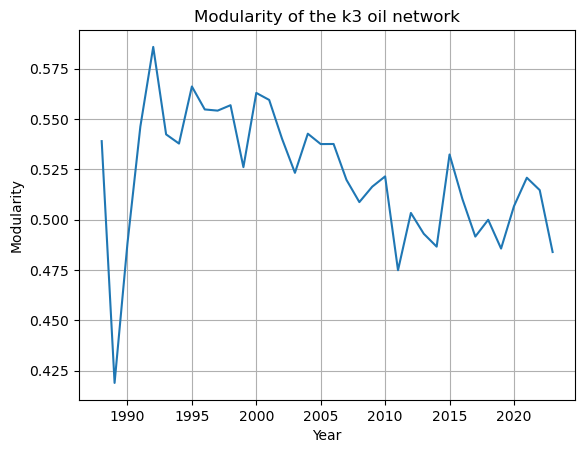

In [17]:
import matplotlib.pyplot as plt
years = [i for i in range(start_year, end_year)]

data_modularity = [modularity[i] for i in years]

plt.plot(years, data_modularity)

plt.xlabel("Year")
plt.ylabel("Modularity")
plt.title(f"Modularity of the k3 oil network")
plt.grid(True)
plt.show()